In [4]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool")
db_path = project_root / "data" / "thesis_database.db"

conn = sqlite3.connect(db_path)

In [6]:
query = """
SELECT *
FROM Prices
"""

df_prices = pd.read_sql_query(query, conn)

df_prices.head()

,price_id,zone_id,delivery_day,hour,price_value
0,1,1,2020-01-01,0,28.78
1,2,2,2020-01-01,0,28.78
2,3,3,2020-01-01,0,28.78
3,4,4,2020-01-01,0,41.88
4,5,5,2020-01-01,0,41.88


In [7]:
# Filter a single zone
df = df_prices[df_prices["zone_id"] == 12].copy()

In [8]:
# Create datetime column from date and hour
df["datetime"] = (
    pd.to_datetime(df["delivery_day"]) 
    + pd.to_timedelta(df["hour"], unit="h")
)

In [9]:
# Sort by datetime
df = df.sort_values("datetime")

In [10]:
# Localize to Oslo timezone and convert to UTC
df["datetime"] = (
    df["datetime"]
    .dt.tz_localize("Europe/Oslo", ambiguous="infer", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

In [11]:
# Sort again after timezone conversion
df = df.sort_values("datetime")

In [12]:
# Set datetime as index
df = df.set_index("datetime")

In [ ]:
import sys

sys.path.append(str(Path().resolve().parent))
from src.events import SimpleEventDetector

detector = SimpleEventDetector()

df_price_events = detector.detect_price_events(df)

In [35]:
df_price_events.index

DatetimeIndex(['2019-12-31 23:00:00', '2020-01-01 00:00:00',
               '2020-01-01 01:00:00', '2020-01-01 02:00:00',
               '2020-01-01 03:00:00', '2020-01-01 04:00:00',
               '2020-01-01 05:00:00', '2020-01-01 06:00:00',
               '2020-01-01 07:00:00', '2020-01-01 08:00:00',
               ...
               '2025-09-30 12:00:00', '2025-09-30 13:00:00',
               '2025-09-30 14:00:00', '2025-09-30 15:00:00',
               '2025-09-30 16:00:00', '2025-09-30 17:00:00',
               '2025-09-30 18:00:00', '2025-09-30 19:00:00',
               '2025-09-30 20:00:00', '2025-09-30 21:00:00'],
              dtype='datetime64[ns]', name='datetime', length=50399, freq=None)

In [20]:
# Target: next hour price
df_price_events["target"] = df_price_events["price_value"].shift(-1)

In [21]:
df_price_events["price_lag_1"] = df_price_events["price_value"].shift(1)
df_price_events["price_lag_2"] = df_price_events["price_value"].shift(2)
df_price_events["price_lag_24"] = df_price_events["price_value"].shift(24)

In [22]:
df_price_events["hour"] = df_price_events.index.hour
df_price_events["day_of_week"] = df_price_events.index.dayofweek

In [23]:
event_cols = [
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "high_volatility"
]

df_price_events[event_cols] = df_price_events[event_cols].astype(int)

In [24]:
features = [
    "price_value",
    "price_lag_1",
    "price_lag_2",
    "price_lag_24",
    "price_delta",
    "abs_price_delta",
    "rolling_volatility_24h",
    "hour",
    "day_of_week"
] + event_cols

df_model = df_price_events.dropna(subset=features + ["target"])

In [25]:
# Use only 2020
df_model_2020 = df_model[
    (df_model.index >= "2020-01-01") &
    (df_model.index <= "2020-12-31 23:00:00")
].copy()

# Train/test split for one-week short-term evaluation
train = df_model_2020[
    (df_model_2020.index >= "2020-01-01") &
    (df_model_2020.index <= "2020-11-30 23:00:00")
]

test = df_model_2020[
    (df_model_2020.index >= "2020-12-01") &
    (df_model_2020.index <= "2020-12-07 23:00:00")
]

In [26]:
X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

In [27]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)

pred_series = pd.Series(y_pred, index=X_test.index)
real_series = pd.Series(y_test.values, index=X_test.index)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(real_series, pred_series)
rmse = np.sqrt(mean_squared_error(real_series, pred_series))
r2 = r2_score(real_series, pred_series)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.865998169798585
RMSE: 1.4304390029506915
R2: 0.804089486061578


In [30]:
threshold = real_series.quantile(0.98)

peak_mask = real_series > threshold

mae_peaks = mean_absolute_error(
    real_series[peak_mask],
    pred_series[peak_mask]
)

print("MAE Peaks:", mae_peaks)
print("Number of peak points:", peak_mask.sum())

MAE Peaks: 1.0006275807573326
Number of peak points: 4


In [33]:
lags = range(-5, 6)

corrs = [
    real_series.corr(pred_series.shift(lag))
    for lag in lags
]

best_lag = lags[np.argmax(corrs)]

print("Best lag:", best_lag)

Best lag: -1


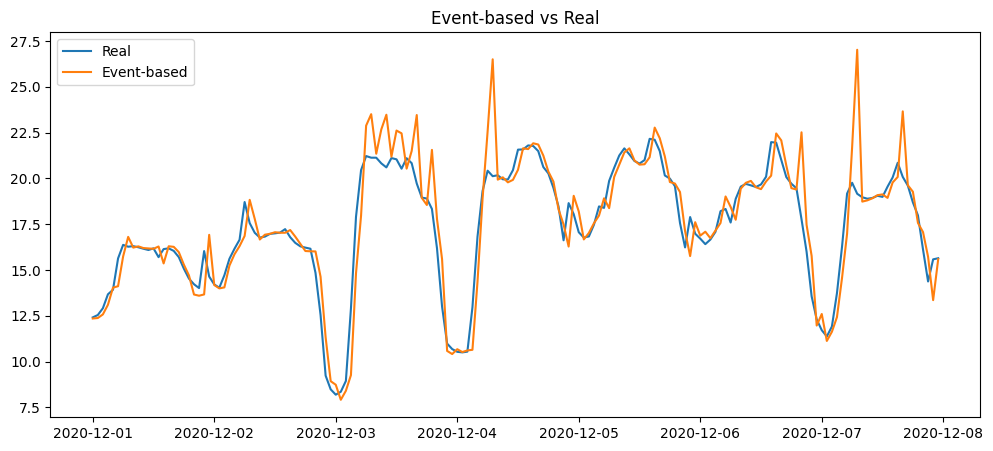

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(real_series, label="Real")
plt.plot(pred_series, label="Event-based")
plt.legend()
plt.title("Event-based vs Real")
plt.show()

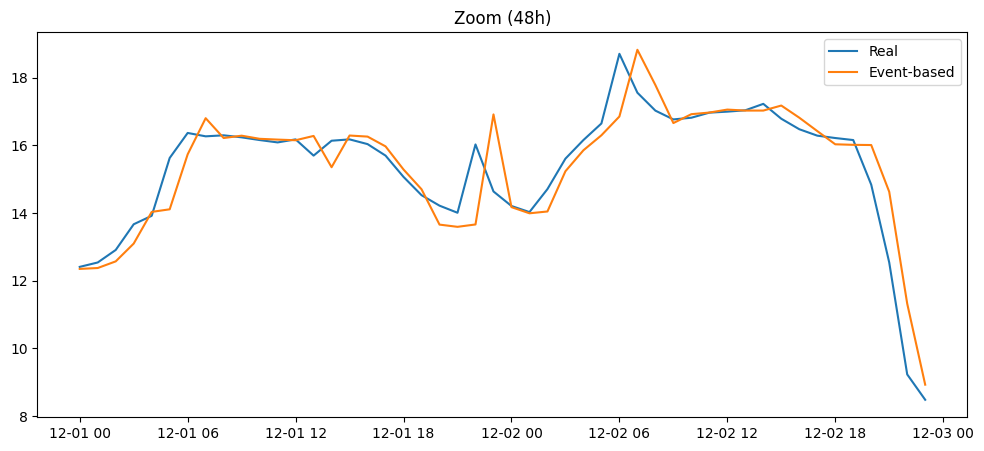

In [32]:
plt.figure(figsize=(12,5))
plt.plot(real_series[:48], label="Real")
plt.plot(pred_series[:48], label="Event-based")
plt.legend()
plt.title("Zoom (48h)")
plt.show()